# NYC Precipitation

Pipeline local para:

- leer `data/temporal/noaa/precipitation.csv`
- usar solo las 4 estaciones presentes en ese CSV
- construir poligonos de Thiessen recortados a NYC
- detectar eventos de lluvia horarios
- cruzar Thiessen con la red de calles

Reglas de eventos:

- separacion minima seca: `6` horas
- profundidad minima del evento: `1.1` mm
- `duration` se calcula con el ultimo timestamp humedo mas el intervalo nominal de muestreo de la estacion


In [1]:
import os
from pathlib import Path

import geopandas as gpd
import pandas as pd
from shapely import make_valid
from shapely.geometry import MultiPoint
from shapely.ops import unary_union, voronoi_diagram

MPLCONFIGDIR = Path("/tmp/matplotlib")
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "data").exists():
            return candidate
    return current


ROOT = find_project_root()
LOCAL_CRS = "EPSG:2263"

PRECIP_PATH = ROOT / "data" / "temporal" / "noaa" / "precipitation.csv"
STATION_METADATA_PATH = ROOT / "data" / "temporal" / "noaa" / "4308211.csv"
NYC_BOUNDARY_PATH = ROOT / "data" / "spatial" / "vector" / "nyc_borough_boundary" / "nybb.geojson"
STREETS_PATH = ROOT / "data" / "spatial" / "vector" / "streets" / "processed" / "lion_metrics.gpkg"

STATION_POINTS_OUTPUT = ROOT / "data" / "spatial" / "vector" / "noaa" / "precipitation_station_points.geojson"
THIESSEN_OUTPUT = ROOT / "data" / "spatial" / "vector" / "noaa" / "precipitation_thiessen.geojson"
RECORDS_OUTPUT = ROOT / "data" / "processed" / "precipitation" / "hourly" / "precipitation_records.csv"
EVENTS_OUTPUT = ROOT / "data" / "processed" / "precipitation" / "events_hourly" / "precipitation_events.csv"
CROSSWALK_OUTPUT = ROOT / "data" / "spatial" / "vector" / "noaa" / "precipitation_segment_station_crosswalk.csv"

PRECIP_INPUT_UNIT = "inch"
EVENT_DRY_GAP_HOURS = 6
MIN_EVENT_DEPTH_MM = 1.1
VORONOI_BUFFER_FEET = 5000

for output_path in [
    STATION_POINTS_OUTPUT,
    THIESSEN_OUTPUT,
    RECORDS_OUTPUT,
    EVENTS_OUTPUT,
    CROSSWALK_OUTPUT,
]:
    output_path.parent.mkdir(parents=True, exist_ok=True)


def unit_factor_to_mm(unit: str) -> float:
    unit = unit.strip().lower()
    if unit in {"inch", "inches", "in"}:
        return 25.4
    if unit in {"mm", "millimeter", "millimeters"}:
        return 1.0
    raise ValueError(f"Unsupported precipitation unit: {unit}")


def load_nyc_boundary() -> tuple[gpd.GeoDataFrame, object]:
    boroughs = gpd.read_file(NYC_BOUNDARY_PATH)
    boroughs = boroughs.to_crs(LOCAL_CRS)
    boroughs["geometry"] = boroughs.geometry.map(make_valid)
    boundary = unary_union(boroughs.geometry)
    return boroughs, boundary


def load_station_points() -> gpd.GeoDataFrame:
    stations_in_csv = pd.read_csv(PRECIP_PATH, usecols=["STATION"]).drop_duplicates()
    stations_in_csv = stations_in_csv.rename(columns={"STATION": "station_p_id"})

    metadata = pd.read_csv(
        STATION_METADATA_PATH,
        usecols=["STATION", "NAME", "LATITUDE", "LONGITUDE"],
    ).drop_duplicates()
    metadata = metadata.rename(
        columns={
            "STATION": "station_p_id",
            "NAME": "station_name",
            "LATITUDE": "latitude",
            "LONGITUDE": "longitude",
        }
    )

    stations = stations_in_csv.merge(metadata, on="station_p_id", how="left", validate="one_to_one")
    missing = stations.loc[stations[["latitude", "longitude"]].isna().any(axis=1), "station_p_id"].tolist()
    if missing:
        raise ValueError(f"Station metadata missing for: {missing}")

    station_points = gpd.GeoDataFrame(
        stations,
        geometry=gpd.points_from_xy(stations["longitude"], stations["latitude"]),
        crs="EPSG:4326",
    )
    return station_points


def load_precipitation_records() -> pd.DataFrame:
    records = pd.read_csv(
        PRECIP_PATH,
        usecols=["STATION", "DATE", "REPORT_TYPE", "SOURCE", "HourlyPrecipitation"],
        low_memory=False,
    )
    records = records.rename(
        columns={
            "STATION": "station_p_id",
            "DATE": "timestamp",
            "REPORT_TYPE": "report_type",
            "SOURCE": "source",
            "HourlyPrecipitation": "depth_raw",
        }
    )
    records["timestamp"] = pd.to_datetime(records["timestamp"], errors="coerce")

    raw = records["depth_raw"].astype("string").str.strip()
    trace_mask = raw.str.upper().isin({"T", "TRACE"})
    raw = raw.str.replace(r"[^0-9eE+\-.]", "", regex=True)
    records["depth_raw"] = pd.to_numeric(raw, errors="coerce")
    records.loc[trace_mask, "depth_raw"] = 0.0

    factor = unit_factor_to_mm(PRECIP_INPUT_UNIT)
    records["depth"] = records["depth_raw"] * factor

    records = records.dropna(subset=["timestamp"]).copy()
    records = (
        records.groupby(["station_p_id", "timestamp"], as_index=False)
        .agg(
            depth=("depth", lambda s: s.dropna().max() if s.notna().any() else pd.NA),
            report_type=("report_type", lambda s: "|".join(sorted({str(v) for v in s.dropna() if str(v)}))),
            source=("source", "first"),
        )
        .sort_values(["station_p_id", "timestamp"])
        .reset_index(drop=True)
    )
    records["depth"] = pd.to_numeric(records["depth"], errors="coerce")
    records = conditionally_impute_precipitation(records)
    records = records.loc[records["depth"].notna()].copy()
    records = records.loc[records["depth"] >= 0].copy()
    return records


def infer_station_intervals(records: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for station_p_id, group in records.groupby("station_p_id", sort=True):
        timestamps = group["timestamp"].sort_values().drop_duplicates()
        deltas = timestamps.diff().dropna()
        deltas = deltas[deltas > pd.Timedelta(0)]
        if deltas.empty:
            interval_minutes = 60
        else:
            minutes = (deltas.dt.total_seconds() / 60).round().astype(int)
            interval_minutes = int(minutes.mode().iloc[0]) if not minutes.mode().empty else int(round(minutes.median()))
            interval_minutes = max(interval_minutes, 1)
        rows.append(
            {
                "station_p_id": station_p_id,
                "interval_minutes": interval_minutes,
                "interval_hours": interval_minutes / 60.0,
            }
        )
    return pd.DataFrame(rows)


def conditionally_impute_precipitation(records: pd.DataFrame) -> pd.DataFrame:
    frames = []
    for station_p_id, group in records.groupby("station_p_id", sort=True):
        group = group.sort_values("timestamp").copy()
        group["depth_observed"] = group["depth"]
        group["fill_method"] = pd.NA

        prev_value = group["depth_observed"].ffill()
        next_value = group["depth_observed"].bfill()
        interpolated = group.set_index("timestamp")["depth_observed"].interpolate(method="time", limit_area="inside")

        group["depth"] = group["depth_observed"]
        gap_mask = group["depth_observed"].isna() & prev_value.notna() & next_value.notna()
        zero_guard_mask = gap_mask & ((prev_value <= 0) | (next_value <= 0))
        positive_interp_mask = gap_mask & (prev_value > 0) & (next_value > 0)

        group.loc[zero_guard_mask, "depth"] = 0.0
        group.loc[zero_guard_mask, "fill_method"] = "zero_guard"
        group.loc[positive_interp_mask, "depth"] = interpolated.loc[group.loc[positive_interp_mask, "timestamp"]].to_numpy()
        group.loc[positive_interp_mask, "fill_method"] = "linear_positive"
        group["was_interpolated"] = group["fill_method"].notna()
        frames.append(group)

    return pd.concat(frames, ignore_index=True) if frames else records.copy()


def build_rain_events(records: pd.DataFrame, intervals: pd.DataFrame) -> pd.DataFrame:
    interval_lookup = intervals.set_index("station_p_id")["interval_minutes"].to_dict()
    wet_records = records.loc[records["depth"] > 0].copy()
    event_frames = []

    for station_p_id, group in wet_records.groupby("station_p_id", sort=True):
        group = group.sort_values("timestamp").copy()
        interval_minutes = int(interval_lookup.get(station_p_id, 60))
        interval_delta = pd.Timedelta(minutes=interval_minutes)
        previous_end = group["timestamp"].shift(1) + interval_delta
        dry_gap = group["timestamp"] - previous_end
        group["event_group"] = dry_gap.isna() | (dry_gap >= pd.Timedelta(hours=EVENT_DRY_GAP_HOURS))
        group["event_group"] = group["event_group"].cumsum()

        station_events = (
            group.groupby("event_group", as_index=False)
            .agg(
                start=("timestamp", "min"),
                last_observation=("timestamp", "max"),
                depth=("depth", "sum"),
            )
            .copy()
        )
        station_events["end"] = station_events["last_observation"] + interval_delta
        station_events["duration"] = (station_events["end"] - station_events["start"]).dt.total_seconds() / 3600.0
        station_events["duration"] = station_events["duration"].clip(lower=interval_minutes / 60.0)
        station_events["intensity"] = station_events["depth"] / station_events["duration"]
        station_events["station_p_id"] = station_p_id
        station_events = station_events.loc[station_events["depth"] >= MIN_EVENT_DEPTH_MM].copy()
        event_frames.append(station_events[["station_p_id", "start", "end", "duration", "intensity", "depth"]])

    if not event_frames:
        return pd.DataFrame(columns=["event_id", "station_p_id", "start", "end", "duration", "intensity", "depth"])

    events = pd.concat(event_frames, ignore_index=True)
    events = events.sort_values(["station_p_id", "start"]).reset_index(drop=True)
    events.insert(0, "event_id", [f"P_EVENT_{i:06d}" for i in range(1, len(events) + 1)])
    return events


def build_thiessen_polygons(station_points: gpd.GeoDataFrame, nyc_boundary) -> gpd.GeoDataFrame:
    station_points_local = station_points.to_crs(LOCAL_CRS)
    source_points = MultiPoint(list(station_points_local.geometry))
    voronoi = voronoi_diagram(
        source_points,
        envelope=nyc_boundary.envelope.buffer(VORONOI_BUFFER_FEET),
        edges=False,
    )
    cells = gpd.GeoDataFrame(geometry=list(voronoi.geoms), crs=LOCAL_CRS)
    cells["geometry"] = cells.geometry.map(make_valid)
    cells["geometry"] = cells.geometry.intersection(nyc_boundary)
    cells = cells.loc[~cells.geometry.is_empty].copy()

    label_points = gpd.GeoDataFrame(
        {"cell_id": range(len(cells))},
        geometry=cells.representative_point(),
        crs=LOCAL_CRS,
    )
    assigned = gpd.sjoin_nearest(
        label_points,
        station_points_local[["station_p_id", "station_name", "latitude", "longitude", "geometry"]],
        how="left",
        distance_col="distance_to_station",
    )

    thiessen = cells.reset_index(drop=True).join(
        assigned[["station_p_id", "station_name", "latitude", "longitude", "distance_to_station"]]
    )
    thiessen = thiessen[["station_p_id", "station_name", "latitude", "longitude", "geometry"]].copy()
    thiessen = thiessen.drop_duplicates("station_p_id").reset_index(drop=True)
    return thiessen


def build_segment_crosswalk(thiessen: gpd.GeoDataFrame) -> pd.DataFrame:
    streets = gpd.read_file(STREETS_PATH, columns=["SegmentID", "geometry"]).to_crs(LOCAL_CRS)
    street_points = gpd.GeoDataFrame(
        {"segment_id": streets["SegmentID"].astype("Int64")},
        geometry=streets.representative_point(),
        crs=LOCAL_CRS,
    )

    direct = gpd.sjoin(
        street_points,
        thiessen[["station_p_id", "geometry"]],
        how="left",
        predicate="within",
    )
    direct = direct[["segment_id", "station_p_id", "geometry"]].copy()
    direct = direct.sort_values(["segment_id", "station_p_id"], kind="stable").drop_duplicates("segment_id")

    missing_mask = direct["station_p_id"].isna()
    if missing_mask.any():
        missing = direct.loc[missing_mask, ["segment_id", "geometry"]].copy()
        nearest = gpd.sjoin_nearest(
            missing,
            thiessen[["station_p_id", "geometry"]],
            how="left",
            distance_col="distance_to_polygon",
        )
        nearest = nearest[["segment_id", "station_p_id"]].drop_duplicates("segment_id")
        nearest_lookup = nearest.set_index("segment_id")["station_p_id"]
        direct.loc[missing_mask, "station_p_id"] = direct.loc[missing_mask, "segment_id"].map(nearest_lookup)

    direct = direct.drop(columns=["geometry"])

    crosswalk = direct[["segment_id", "station_p_id"]].dropna().copy()
    crosswalk["segment_id"] = crosswalk["segment_id"].astype("Int64")
    crosswalk = crosswalk.sort_values("segment_id", kind="stable").drop_duplicates("segment_id").reset_index(drop=True)
    return crosswalk


In [2]:
nyc_boroughs, nyc_boundary = load_nyc_boundary()
station_points = load_station_points()
records = load_precipitation_records()
intervals = infer_station_intervals(records)

station_points.to_file(STATION_POINTS_OUTPUT, driver="GeoJSON")
records.to_csv(RECORDS_OUTPUT, index=False)

interpolation_summary = (
    records.groupby("station_p_id", as_index=False)
    .agg(
        n_rows=("station_p_id", "size"),
        n_missing_after_fill=("depth", lambda s: int(s.isna().sum())),
        n_interpolated=("was_interpolated", "sum"),
        n_zero_guard=("fill_method", lambda s: int((s == "zero_guard").sum())),
        n_linear_positive=("fill_method", lambda s: int((s == "linear_positive").sum())),
    )
    .sort_values("station_p_id")
)

print(f"Stations found in precipitation.csv: {len(station_points):,}")
display(station_points.drop(columns="geometry"))

print(f"Hourly precipitation records: {len(records):,}")
display(intervals)
display(interpolation_summary)


Stations found in precipitation.csv: 4


,station_p_id,station_name,latitude,longitude
0,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925
1,USW00014734,"NEWARK LIBERTY INTERNATIONAL AIRPORT, NJ US",40.68275,-74.16927
2,USW00014732,"LAGUARDIA AIRPORT, NY US",40.77945,-73.88027
3,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",40.63915,-73.76390


Hourly precipitation records: 726,803


,station_p_id,interval_minutes,interval_hours
0,USW00014732,60,1.0
1,USW00014734,60,1.0
2,USW00094728,60,1.0
3,USW00094789,60,1.0


,station_p_id,n_rows,n_missing_after_fill,n_interpolated,n_zero_guard,n_linear_positive
0,USW00014732,195895,0,64013,60783,3230
1,USW00014734,174479,0,44290,42254,2036
2,USW00094728,165960,0,31435,28592,2843
3,USW00094789,190469,0,63986,60429,3557


In [3]:
events = build_rain_events(records, intervals)
events.to_csv(EVENTS_OUTPUT, index=False)

station_event_summary = (
    events.groupby("station_p_id", as_index=False)
    .agg(
        n_events=("event_id", "size"),
        mean_duration_hours=("duration", "mean"),
        mean_depth_mm=("depth", "mean"),
        mean_intensity_mm_per_hr=("intensity", "mean"),
    )
    .sort_values("n_events", ascending=False)
)

print(f"Rain events: {len(events):,}")
display(station_event_summary)
display(events.head(10))


Rain events: 4,964


,station_p_id,n_events,mean_duration_hours,mean_depth_mm,mean_intensity_mm_per_hr
2,USW00094728,1283,9.483983,36.438901,4.77469
0,USW00014732,1257,9.005701,27.763545,3.684919
1,USW00014734,1213,9.265499,26.041352,3.665677
3,USW00094789,1211,9.230498,24.583772,3.218196


,event_id,station_p_id,start,end,duration,intensity,depth
0,P_EVENT_000001,USW00014732,2012-01-01 20:51:00,2012-01-01 21:51:00,1.000000,1.524,1.524
1,P_EVENT_000002,USW00014732,2012-01-11 22:51:00,2012-01-12 13:51:00,15.000000,3.924754,58.87131
2,P_EVENT_000003,USW00014732,2012-01-16 23:51:00,2012-01-17 16:51:00,17.000000,0.558602,9.496231
3,P_EVENT_000004,USW00014732,2012-01-21 03:33:00,2012-01-21 13:51:00,10.300000,1.557803,16.045372
4,P_EVENT_000005,USW00014732,2012-01-23 10:27:00,2012-01-24 00:51:00,14.400000,0.994833,14.3256
5,P_EVENT_000006,USW00014732,2012-01-26 16:23:00,2012-01-27 00:51:00,8.466667,0.958857,8.118324
6,P_EVENT_000007,USW00014732,2012-01-27 07:47:00,2012-01-27 13:51:00,6.066667,3.01311,18.279533
7,P_EVENT_000008,USW00014732,2012-02-01 06:51:00,2012-02-01 08:51:00,2.000000,0.61595,1.2319
8,P_EVENT_000009,USW00014732,2012-02-11 03:51:00,2012-02-11 10:51:00,7.000000,0.544286,3.81
9,P_EVENT_000010,USW00014732,2012-02-16 12:51:00,2012-02-17 07:51:00,19.000000,0.444412,8.443837


In [4]:
thiessen = build_thiessen_polygons(station_points, nyc_boundary)
thiessen.to_crs("EPSG:4326").to_file(THIESSEN_OUTPUT, driver="GeoJSON")

crosswalk = build_segment_crosswalk(thiessen)
crosswalk.to_csv(CROSSWALK_OUTPUT, index=False)

print(f"Thiessen polygons: {len(thiessen):,}")
print(f"Street crosswalk rows: {len(crosswalk):,}")
display(thiessen.drop(columns="geometry"))
display(crosswalk.head(10))


Thiessen polygons: 4
Street crosswalk rows: 173,877


,station_p_id,station_name,latitude,longitude
0,USW00014734,"NEWARK LIBERTY INTERNATIONAL AIRPORT, NJ US",40.68275,-74.16927
1,USW00094789,"JFK INTERNATIONAL AIRPORT, NY US",40.63915,-73.76390
2,USW00094728,"NY CITY CENTRAL PARK, NY US",40.77898,-73.96925
3,USW00014732,"LAGUARDIA AIRPORT, NY US",40.77945,-73.88027


,segment_id,station_p_id
0,16,USW00014734
1,20,USW00014734
2,26,USW00014734
3,29,USW00014734
4,30,USW00014734
5,31,USW00014734
6,32,USW00014734
7,33,USW00014734
8,36,USW00014734
9,51,USW00014734


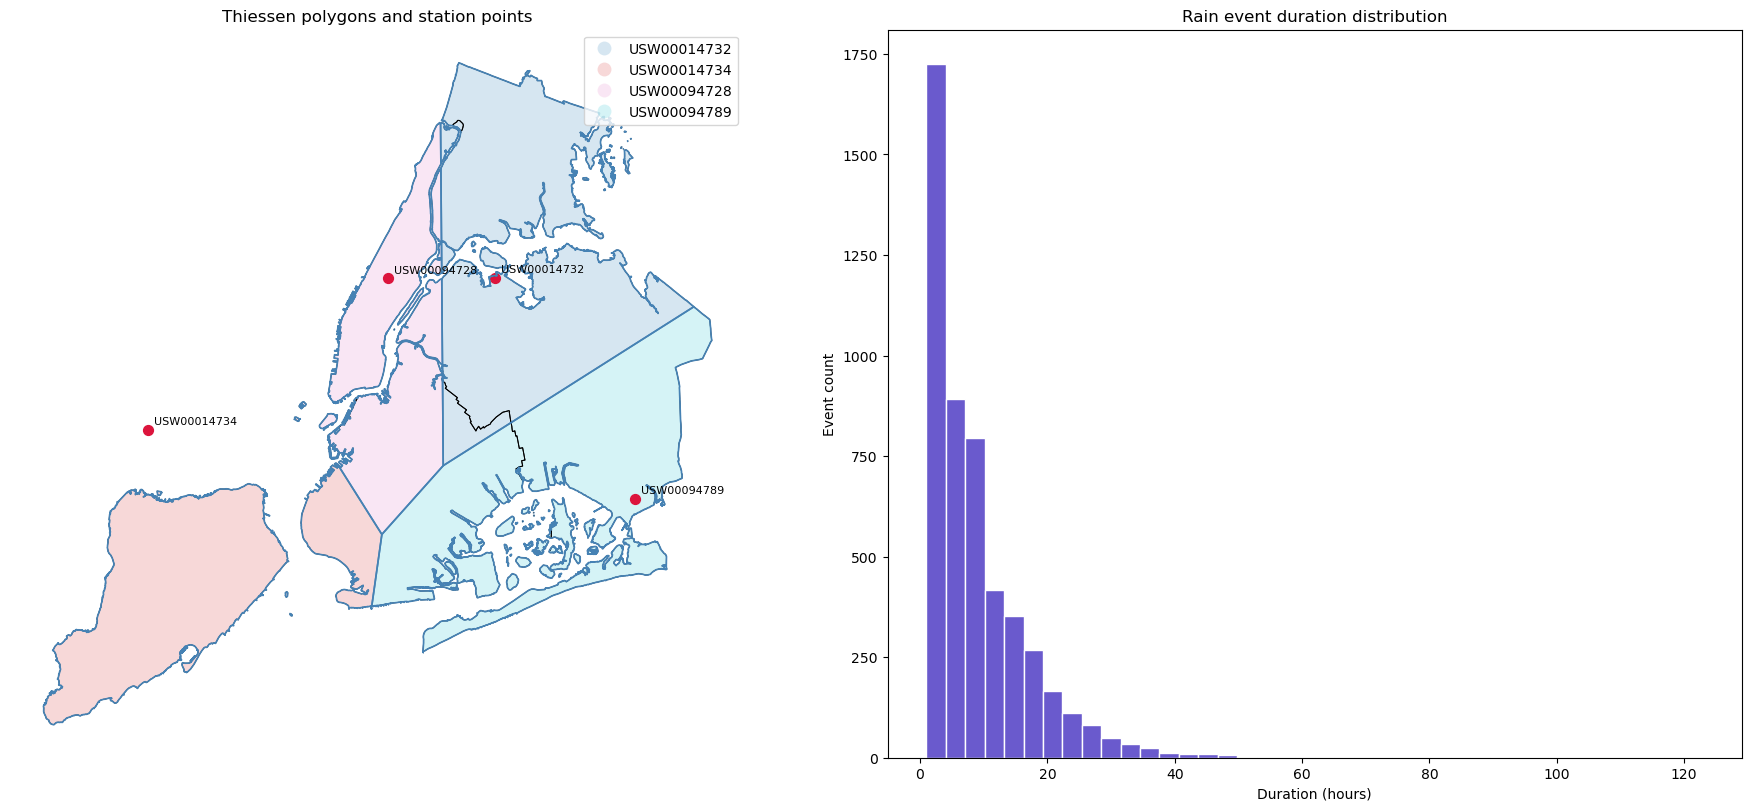

Outputs
- station points: /home/map10194/Documents/urban-flood-stress/data/spatial/vector/noaa/precipitation_station_points.geojson
- hourly records: /home/map10194/Documents/urban-flood-stress/data/processed/precipitation/hourly/precipitation_records.csv
- rain events: /home/map10194/Documents/urban-flood-stress/data/processed/precipitation/events_hourly/precipitation_events.csv
- thiessen polygons: /home/map10194/Documents/urban-flood-stress/data/spatial/vector/noaa/precipitation_thiessen.geojson
- street crosswalk: /home/map10194/Documents/urban-flood-stress/data/spatial/vector/noaa/precipitation_segment_station_crosswalk.csv


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

nyc_boroughs.boundary.plot(ax=axes[0], color="black", linewidth=0.7)
thiessen.boundary.plot(ax=axes[0], color="steelblue", linewidth=1.2)
thiessen.plot(ax=axes[0], column="station_p_id", alpha=0.18, categorical=True, legend=True)
station_points.to_crs(LOCAL_CRS).plot(ax=axes[0], color="crimson", markersize=50)
for _, row in station_points.to_crs(LOCAL_CRS).iterrows():
    axes[0].annotate(row["station_p_id"], (row.geometry.x, row.geometry.y), xytext=(4, 4), textcoords="offset points", fontsize=8)
axes[0].set_title("Thiessen polygons and station points")
axes[0].set_axis_off()

events["duration"].plot(kind="hist", bins=40, ax=axes[1], color="slateblue", edgecolor="white")
axes[1].set_title("Rain event duration distribution")
axes[1].set_xlabel("Duration (hours)")
axes[1].set_ylabel("Event count")

plt.show()

print("Outputs")
print(f"- station points: {STATION_POINTS_OUTPUT}")
print(f"- hourly records: {RECORDS_OUTPUT}")
print(f"- rain events: {EVENTS_OUTPUT}")
print(f"- thiessen polygons: {THIESSEN_OUTPUT}")
print(f"- street crosswalk: {CROSSWALK_OUTPUT}")
